# Final Road Closure Comparison

This notebook compares random road closures with closures of frequently used roads. Both strategies are tested using the same network, deliveries and number of closed roads.

In [1]:
from google.colab import files

uploaded_files = files.upload()

Saving experiments.py to experiments.py
Saving model.py to model.py


In [2]:
import os
import shutil

os.makedirs("src", exist_ok=True)

for filename in ["model.py", "experiments.py"]:
    if os.path.exists(filename):
        shutil.move(filename, f"src/{filename}")

open("src/__init__.py", "a").close()

import pandas as pd
import matplotlib.pyplot as plt

from src.model import (
    create_road_network,
    get_delivery_locations,
    assign_customers_to_restaurants,
    calculate_delivery_routes,
    count_road_usage,
    select_high_use_roads,
    close_roads,
    calculate_scenario_results
)

from src.experiments import (
    repeat_random_closures,
    summarise_random_results
)

print("Model files imported successfully")

Model files imported successfully


## 1. Create the baseline model

The same road network, restaurant locations, customer locations and delivery assignments are used in every experiment. This keeps the comparison fair.

In [3]:
road_network = create_road_network()

restaurants, customers = get_delivery_locations()

assignments = assign_customers_to_restaurants(
    road_network,
    restaurants,
    customers
)

baseline_routes, baseline_distances, baseline_unreachable = (
    calculate_delivery_routes(
        road_network,
        assignments
    )
)

road_usage = count_road_usage(baseline_routes)

average_baseline_distance = (
    sum(baseline_distances.values()) /
    len(baseline_distances)
)

print("Number of roads:", road_network.number_of_edges())
print("Number of restaurants:", len(restaurants))
print("Number of customers:", len(customers))
print("Baseline average distance:", round(average_baseline_distance, 2))
print("Unreachable customers:", len(baseline_unreachable))

Number of roads: 60
Number of restaurants: 3
Number of customers: 15
Baseline average distance: 5.07
Unreachable customers: 0


## 2. Compare the two closure strategies

The experiment tests several closure levels. Random closures are repeated 100 times using different seeds. Frequently used road closures are deterministic because the roads are selected from the baseline usage ranking.

In [7]:
closure_levels = [1, 2, 3, 4, 5, 6, 8, 10]
comparison_results = []

for number_of_closures in closure_levels:

    random_runs = repeat_random_closures(
        road_network,
        assignments,
        baseline_distances,
        number_of_closures,
        repetitions=100
    )

    random_summary = summarise_random_results(random_runs)

    high_use_roads = select_high_use_roads(
        road_usage,
        number_of_closures
    )

    high_use_network = close_roads(
        road_network,
        high_use_roads
    )

    high_use_routes, high_use_distances, high_use_unreachable = (
        calculate_delivery_routes(
            high_use_network,
            assignments
        )
    )

    high_use_results = calculate_scenario_results(
        baseline_distances,
        high_use_distances,
        len(customers)
    )

    comparison_results.append({
        "roads_closed": number_of_closures,
        "random_distance_increase":
            random_summary["mean_distance_increase_percentage"],
        "random_distance_std":
            random_summary["distance_increase_standard_deviation"],
        "random_reachable":
            random_summary["mean_reachable_percentage"],
        "random_reachable_std":
            random_summary["reachable_percentage_standard_deviation"],
        "high_use_distance_increase":
            high_use_results["distance_increase_percentage"],
        "high_use_reachable":
            high_use_results["reachable_percentage"]
    })

results_table = pd.DataFrame(comparison_results)
results_table.round(2)

,roads_closed,random_distance_increase,random_distance_std,random_reachable,random_reachable_std,high_use_distance_increase,high_use_reachable
0,1,3.53,6.83,100.00,0.00,18.42,100.00
1,2,6.05,8.50,100.00,0.00,21.05,100.00
2,3,10.03,10.88,100.00,0.00,56.58,100.00
3,4,14.39,13.12,100.00,0.00,79.41,46.67
4,5,18.83,15.07,99.53,3.58,79.41,46.67
5,6,21.55,15.71,99.87,1.33,85.29,46.67
6,8,28.57,18.82,97.87,9.75,85.29,46.67
7,10,35.82,20.92,96.67,11.47,85.29,46.67


## 3. Delivery distance comparison

This graph compares the average distance increase caused by random closures and highest-use road closures. The error bars show the standard deviation across the 100 random runs.

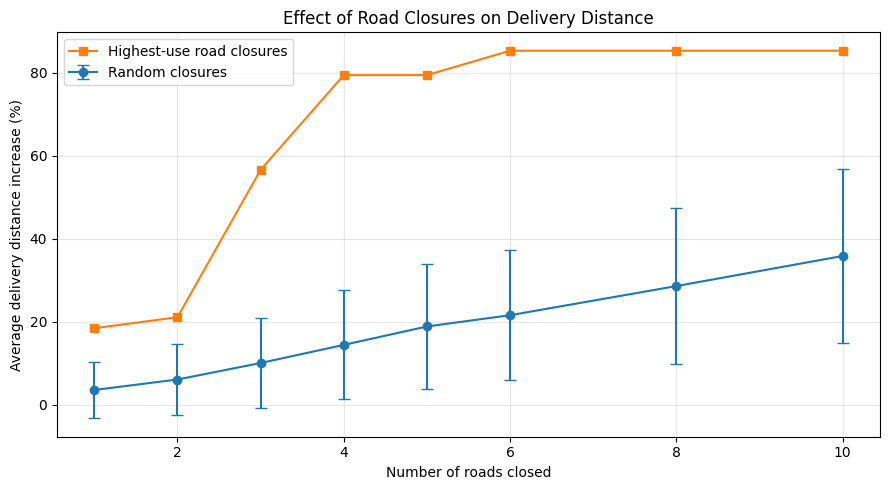

In [5]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    results_table["roads_closed"],
    results_table["random_distance_increase"],
    yerr=results_table["random_distance_std"],
    marker="o",
    capsize=4,
    label="Random closures"
)

plt.plot(
    results_table["roads_closed"],
    results_table["high_use_distance_increase"],
    marker="s",
    label="Highest-use road closures"
)

plt.xlabel("Number of roads closed")
plt.ylabel("Average delivery distance increase (%)")
plt.title("Effect of Road Closures on Delivery Distance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "distance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Customer reachability comparison

This graph shows the percentage of customers that can still receive a delivery after roads are closed.

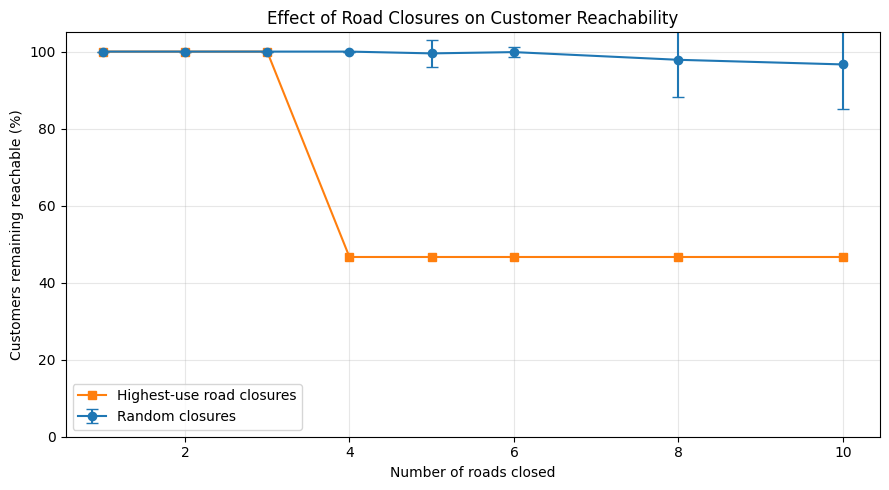

In [8]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    results_table["roads_closed"],
    results_table["random_reachable"],
    yerr=results_table["random_reachable_std"],
    marker="o",
    capsize=4,
    label="Random closures"
)

plt.plot(
    results_table["roads_closed"],
    results_table["high_use_reachable"],
    marker="s",
    label="Highest-use road closures"
)

plt.xlabel("Number of roads closed")
plt.ylabel("Customers remaining reachable (%)")
plt.title("Effect of Road Closures on Customer Reachability")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "reachability_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Traffic congestion sensitivity test

This experiment applies congestion to the three highest-use roads. The congestion multiplier increases their travel cost, while the roads remain open. Drivers can change to another route when it has a lower total travel cost.

In [9]:
from src.model import apply_congestion

congested_roads = select_high_use_roads(road_usage, 3)
congestion_multipliers = [1.0, 1.25, 1.5, 2.0, 3.0]

congestion_results = []

for multiplier in congestion_multipliers:

    congestion_network = apply_congestion(
        road_network,
        congested_roads,
        multiplier
    )

    congestion_routes, congestion_distances, congestion_unreachable = (
        calculate_delivery_routes(
            congestion_network,
            assignments,
            weight="travel_cost"
        )
    )

    scenario_results = calculate_scenario_results(
        baseline_distances,
        congestion_distances,
        len(customers)
    )

    routes_changed = 0

    for customer in customers:
        if congestion_routes[customer] != baseline_routes[customer]:
            routes_changed += 1

    congestion_results.append({
        "congestion_multiplier": multiplier,
        "travel_cost_increase":
            scenario_results["distance_increase_percentage"],
        "routes_changed": routes_changed,
        "customers_reachable":
            scenario_results["reachable_percentage"]
    })

congestion_table = pd.DataFrame(congestion_results)
congestion_table.round(2)

,congestion_multiplier,travel_cost_increase,routes_changed,customers_reachable
0,1.00,0.00,0,100.0
1,1.25,4.61,0,100.0
2,1.50,9.21,1,100.0
3,2.00,15.79,4,100.0
4,3.00,23.68,4,100.0


## 6. Congestion results

The first graph shows how delivery travel cost changes as congestion becomes stronger. The second graph shows how many delivery routes change to avoid congested roads.

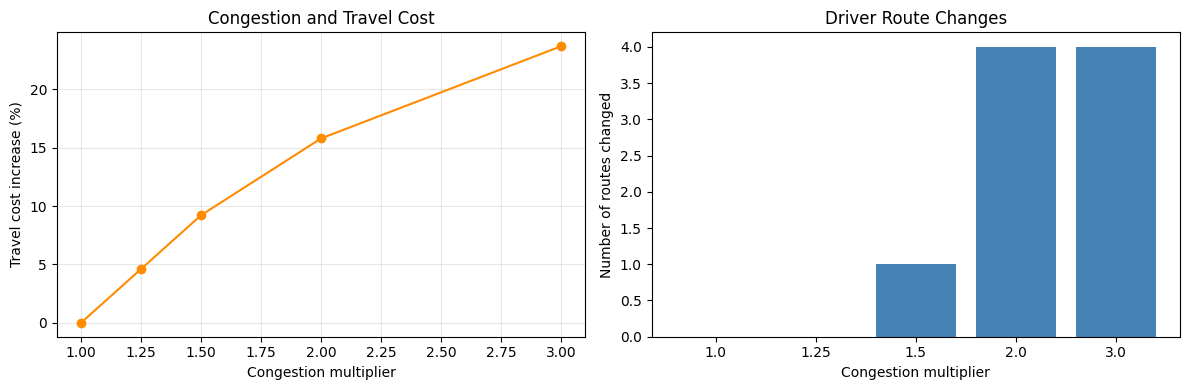

In [10]:
figure, graphs = plt.subplots(1, 2, figsize=(12, 4))

graphs[0].plot(
    congestion_table["congestion_multiplier"],
    congestion_table["travel_cost_increase"],
    marker="o",
    color="darkorange"
)

graphs[0].set_xlabel("Congestion multiplier")
graphs[0].set_ylabel("Travel cost increase (%)")
graphs[0].set_title("Congestion and Travel Cost")
graphs[0].grid(alpha=0.3)

graphs[1].bar(
    congestion_table["congestion_multiplier"].astype(str),
    congestion_table["routes_changed"],
    color="steelblue"
)

graphs[1].set_xlabel("Congestion multiplier")
graphs[1].set_ylabel("Number of routes changed")
graphs[1].set_title("Driver Route Changes")

plt.tight_layout()

plt.savefig(
    "congestion_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
results_table.round(4).to_csv(
    "closure_comparison_results.csv",
    index=False
)

congestion_table.round(4).to_csv(
    "congestion_results.csv",
    index=False
)

print("Result tables saved successfully")

Result tables saved successfully


In [12]:
print("Road closure comparison:")
display(results_table.round(2))

print("\nTraffic congestion results:")
display(congestion_table.round(2))

Road closure comparison:


,roads_closed,random_distance_increase,random_distance_std,random_reachable,random_reachable_std,high_use_distance_increase,high_use_reachable
0,1,3.53,6.83,100.00,0.00,18.42,100.00
1,2,6.05,8.50,100.00,0.00,21.05,100.00
2,3,10.03,10.88,100.00,0.00,56.58,100.00
3,4,14.39,13.12,100.00,0.00,79.41,46.67
4,5,18.83,15.07,99.53,3.58,79.41,46.67
5,6,21.55,15.71,99.87,1.33,85.29,46.67
6,8,28.57,18.82,97.87,9.75,85.29,46.67
7,10,35.82,20.92,96.67,11.47,85.29,46.67



Traffic congestion results:


,congestion_multiplier,travel_cost_increase,routes_changed,customers_reachable
0,1.00,0.00,0,100.0
1,1.25,4.61,0,100.0
2,1.50,9.21,1,100.0
3,2.00,15.79,4,100.0
4,3.00,23.68,4,100.0


## 7. Initial observations

The highest-use road closures caused more disruption than the random closures at every closure level tested. With one road closed, the average distance increase was 18.42% for the highest-use strategy compared with 3.53% for random closures.

The largest change happened when four highest-use roads were closed. Customer reachability dropped from 100% to 46.67%, while the average random experiment still kept 100% of customers reachable. At this level, the distance increase was 79.41% for highest-use closures and 14.39% for random closures.

Random closures produced different results across the repeated runs. The standard deviation increased as more roads were closed, showing that the effect depends on which roads are randomly selected.

The congestion experiment produced a gradual increase in travel cost. At a multiplier of 3.0, travel cost increased by 23.68%, and four delivery routes changed. However, all customers remained reachable because congested roads were still open.

The high-use distance results levelled off after several closures. This is partly because unreachable customers are reported separately and are not included in the average distance calculation. Additional closures also may not affect the routes used by the customers who remain reachable.

Overall, the results support the hypothesis for this synthetic network: roads used by many baseline deliveries are more important to network performance than a typical randomly selected road. However, this result should not automatically be generalised to every real road network.

## 8. Network after four highest-use road closures

Red dashed lines are closed roads. Orange lines are the recalculated delivery routes. Red nodes are restaurants, blue nodes are reachable customers, and black nodes are unreachable customers.

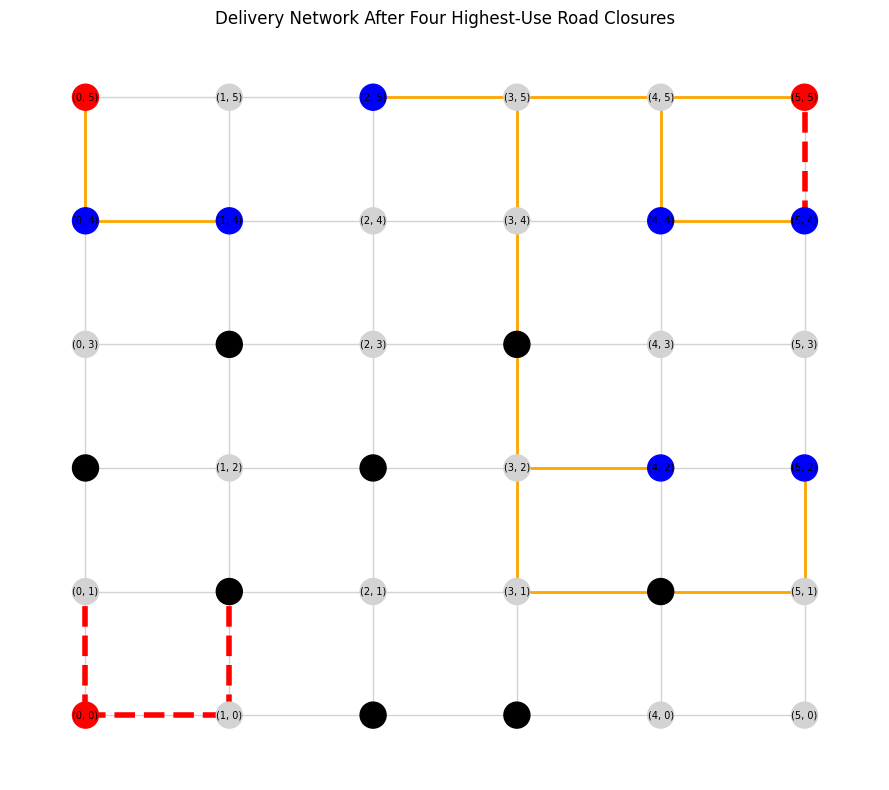

Unreachable customers: [(0, 2), (1, 1), (1, 3), (2, 0), (2, 2), (3, 0), (3, 3), (4, 1)]


In [13]:
import networkx as nx

closed_high_use_roads = select_high_use_roads(road_usage, 4)

disrupted_network = close_roads(
    road_network,
    closed_high_use_roads
)

disrupted_routes, disrupted_distances, disrupted_unreachable = (
    calculate_delivery_routes(
        disrupted_network,
        assignments
    )
)

disrupted_route_roads = set()

for route in disrupted_routes.values():
    for position in range(len(route) - 1):
        road = tuple(sorted([
            route[position],
            route[position + 1]
        ]))
        disrupted_route_roads.add(road)

node_colours = []

for node in road_network.nodes:
    if node in restaurants:
        node_colours.append("red")
    elif node in disrupted_unreachable:
        node_colours.append("black")
    elif node in customers:
        node_colours.append("blue")
    else:
        node_colours.append("lightgray")

positions = {
    node: node
    for node in road_network.nodes
}

plt.figure(figsize=(9, 8))

nx.draw_networkx_edges(
    road_network,
    positions,
    edge_color="lightgray",
    width=1
)

nx.draw_networkx_edges(
    road_network,
    positions,
    edgelist=list(disrupted_route_roads),
    edge_color="orange",
    width=2
)

nx.draw_networkx_edges(
    road_network,
    positions,
    edgelist=closed_high_use_roads,
    edge_color="red",
    width=4,
    style="dashed"
)

nx.draw_networkx_nodes(
    road_network,
    positions,
    node_color=node_colours,
    node_size=350
)

nx.draw_networkx_labels(
    road_network,
    positions,
    font_size=7
)

plt.title("Delivery Network After Four Highest-Use Road Closures")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "high_use_closure_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Unreachable customers:", disrupted_unreachable)